# Case 01 — Retention Intelligence Platform  

### Apple Decision Intelligence Portfolio  
**Author:** Israel Gómez Millán  

---

## Executive Summary

This case presents an end-to-end retention intelligence framework designed to identify subscription churn risk, explain the behavioral causes of disengagement, and operationalize predictive outputs into actionable retention playbooks.

The project simulates a production-style machine learning workflow combining:

- Behavioral Simulation  
- Feature Engineering  
- Predictive Modeling  
- SHAP Explainability  
- Decision Intelligence  

---

### Business Goal

Improve subscription retention by proactively identifying at-risk users before churn occurs and prioritizing interventions by revenue impact.


## 1. Business Problem

Subscription platforms face continuous retention pressure as user engagement fluctuates over time.

The business challenge is not only to predict which users are likely to churn, but also to answer:

- Why are they at risk?
- Which users should be prioritized first?
- What intervention should be recommended?

Without this layer of intelligence, retention strategies become reactive, generic, and inefficient.


## 2. Analytical Objective

This project was designed to answer four core questions:

1. Which users are likely to churn within the next 30 days?
2. Which behavioral signals are most predictive of churn?
3. How should users be prioritized based on both risk and value?
4. Which type of retention action is most appropriate for each user?

The end result is not just a churn model, but a retention intelligence system.


## 3. Solution Architecture

The project was implemented as a modular pipeline:

**Simulation → Features → Modeling → Explainability → Decisioning**

This architecture mirrors production-style analytical workflows where model outputs must ultimately support business decisions, not just technical evaluation.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path("..").resolve()

REPORTS_DIR = PROJECT_ROOT / "reports"
DATA_DIR = PROJECT_ROOT / "data"
ASSETS_DIR = PROJECT_ROOT / "assets"

model_benchmark_path = REPORTS_DIR / "model_benchmark_results.csv"
shap_global_path = REPORTS_DIR / "shap_global_importance.csv"
decision_table_path = REPORTS_DIR / "decision_table.csv"
decision_tier_summary_path = REPORTS_DIR / "decision_tier_summary.csv"
decision_playbook_summary_path = REPORTS_DIR / "decision_playbook_summary.csv"
feature_table_path = DATA_DIR / "features" / "feature_table.csv"
simulation_master_path = DATA_DIR / "raw" / "simulation_master_table.csv"


In [2]:
benchmark_df = pd.read_csv(model_benchmark_path)
shap_global_df = pd.read_csv(shap_global_path)
decision_table_df = pd.read_csv(decision_table_path)
decision_tier_summary_df = pd.read_csv(decision_tier_summary_path)
decision_playbook_summary_df = pd.read_csv(decision_playbook_summary_path)
feature_table_df = pd.read_csv(feature_table_path)
simulation_master_df = pd.read_csv(simulation_master_path)

print("Artifacts loaded successfully.")
print(f"Benchmark rows: {len(benchmark_df):,}")
print(f"Decision rows: {len(decision_table_df):,}")
print(f"Feature table rows: {len(feature_table_df):,}")
print(f"Simulation rows: {len(simulation_master_df):,}")


Artifacts loaded successfully.
Benchmark rows: 6
Decision rows: 2,000
Feature table rows: 10,000
Simulation rows: 10,000


## 4. Simulation Review

The simulation layer generates a synthetic subscription ecosystem with:

- user profile metadata,
- engagement behavior,
- content consumption patterns,
- platform adoption metrics,
- probabilistically calibrated churn labels.

This allows the case to demonstrate end-to-end modeling without relying on proprietary production data.


In [3]:
simulation_master_df.head()

,user_id,signup_date,tenure_days,behavioral_segment,plan,primary_device,region,age_group,bundle_type,num_services,...,completion_rate,skip_rate,content_diversity_score,feature_usage_score,search_activity_last_30d,watchlist_additions_last_30d,days_since_last_session,churn_probability,will_churn_30d,churn_date
0,U000000,2025-03-16,107,casual,individual,desktop,LATAM,35_44,standalone,1,...,0.9019,0.2770,0.3697,0.4078,4,3,16,0.031458,0,NaN
1,U000001,2023-07-28,704,passive,student,desktop,LATAM,45_54,standalone,2,...,0.5867,0.5701,0.2306,0.3987,2,0,16,0.355754,0,NaN
2,U000002,2023-11-09,600,passive,individual,tablet,LATAM,25_34,bundle,1,...,0.6110,0.4399,0.4820,0.2248,2,0,11,0.071456,0,NaN
3,U000003,2024-05-15,412,power,family,mobile,EU,18_24,bundle,5,...,0.7797,0.3829,0.4737,0.8547,15,2,1,0.000339,0,NaN
4,U000004,2024-05-20,407,power,individual,tv,LATAM,25_34,bundle,4,...,0.9175,0.1793,0.9093,0.6209,10,11,10,0.000510,0,NaN


In [4]:
simulation_master_df[
    [
        "sessions_last_30d",
        "watch_time_last_30d",
        "completion_rate",
        "skip_rate",
        "days_since_last_session",
        "will_churn_30d",
    ]
].describe().T

,count,mean,std,min,25%,50%,75%,max
sessions_last_30d,10000.0,12.063700,7.797546,0.0000,6.000000,10.00000,16.000000,58.00
watch_time_last_30d,10000.0,538.238618,494.653810,10.0000,178.205000,380.31500,745.197500,3772.55
completion_rate,10000.0,0.656621,0.159940,0.0697,0.535700,0.65755,0.777625,0.99
skip_rate,10000.0,0.403344,0.171291,0.0100,0.278375,0.40185,0.528600,0.95
days_since_last_session,10000.0,8.853400,10.852911,0.0000,2.000000,5.00000,12.000000,90.00
will_churn_30d,10000.0,0.181700,0.385616,0.0000,0.000000,0.00000,0.000000,1.00


In [5]:
churn_rate = simulation_master_df["will_churn_30d"].mean()
print(f"Observed churn rate: {churn_rate:.2%}")

Observed churn rate: 18.17%


### Simulation Assessment

The synthetic environment was designed to produce a realistic churn scenario with:

- non-trivial class balance,
- plausible overlap between retained and churned users,
- behavioral rather than demographic signal dominance.

This is important because unrealistic simulation can artificially inflate downstream model performance.


## 5. Feature Engineering Review

The feature engineering layer transformed raw user behavior into a cleaner, leakage-aware modeling table.

Feature families included:

- engagement frequency,
- content consumption intensity,
- quality indicators,
- discovery metrics,
- recency features,
- derived behavioral ratios.


In [6]:
feature_table_df.head()

,user_id,tenure_days,plan,primary_device,region,age_group,bundle_type,num_services,sessions_last_30d,active_days_last_30d,...,days_since_last_session,sessions_per_active_day,watch_time_per_active_day,searches_per_session,watchlist_additions_per_session,will_churn_30d,signup_date,behavioral_segment,churn_probability,churn_date
0,U000000,107,individual,desktop,LATAM,35_44,standalone,1,7,2,...,16,3.5000,153.9900,0.5714,0.4286,0,2025-03-16,casual,0.031458,NaN
1,U000001,704,student,desktop,LATAM,45_54,standalone,2,7,7,...,16,1.0000,24.2600,0.2857,0.0000,0,2023-07-28,passive,0.355754,NaN
2,U000002,600,individual,tablet,LATAM,25_34,bundle,1,11,10,...,11,1.1000,45.2280,0.1818,0.0000,0,2023-11-09,passive,0.071456,NaN
3,U000003,412,family,mobile,EU,18_24,bundle,5,27,20,...,1,1.3500,87.2570,0.5556,0.0741,0,2024-05-15,power,0.000339,NaN
4,U000004,407,individual,tv,LATAM,25_34,bundle,4,26,18,...,10,1.4444,90.5989,0.3846,0.4231,0,2024-05-20,power,0.000510,NaN


In [7]:
feature_table_df.shape

(10000, 28)

In [8]:
feature_table_df.columns.tolist()

['user_id',
 'tenure_days',
 'plan',
 'primary_device',
 'region',
 'age_group',
 'bundle_type',
 'num_services',
 'sessions_last_30d',
 'active_days_last_30d',
 'watch_time_last_30d',
 'avg_session_duration_min',
 'completion_rate',
 'skip_rate',
 'content_diversity_score',
 'feature_usage_score',
 'search_activity_last_30d',
 'watchlist_additions_last_30d',
 'days_since_last_session',
 'sessions_per_active_day',
 'watch_time_per_active_day',
 'searches_per_session',
 'watchlist_additions_per_session',
 'will_churn_30d',
 'signup_date',
 'behavioral_segment',
 'churn_probability',
 'churn_date']

### Feature Engineering Design Choice

A key design principle was to keep the feature table interpretable and business-valid.

Columns such as:

- `user_id`
- `behavioral_segment`
- `churn_probability`
- `churn_date`

were intentionally excluded from model fitting or treated as analysis-only fields to avoid shortcut learning and leakage risk.


## 6. Modeling Benchmark

Three models were benchmarked:

- Logistic Regression
- Random Forest
- XGBoost

Champion selection prioritized not only predictive quality, but also operational usefulness through metrics such as:

- ROC-AUC
- PR-AUC
- Lift@10%


In [9]:
benchmark_df

,model_name,split,roc_auc,pr_auc,precision,recall,f1,lift_at_10pct
0,logistic_regression,validation,0.917994,0.722111,0.487218,0.890110,0.629738,4.230769
1,logistic_regression,test,0.905373,0.676792,0.479638,0.876033,0.619883,3.856749
2,random_forest,validation,0.910991,0.705441,0.492038,0.848901,0.622984,4.258242
3,random_forest,test,0.900766,0.645618,0.494400,0.851240,0.625506,3.801653
4,xgboost,validation,0.912751,0.715360,0.666667,0.604396,0.634006,4.313187
5,xgboost,test,0.901404,0.657776,0.628378,0.512397,0.564492,3.856749


In [10]:
benchmark_df.sort_values(["split", "roc_auc"], ascending=[True, False])

,model_name,split,roc_auc,pr_auc,precision,recall,f1,lift_at_10pct
1,logistic_regression,test,0.905373,0.676792,0.479638,0.876033,0.619883,3.856749
5,xgboost,test,0.901404,0.657776,0.628378,0.512397,0.564492,3.856749
3,random_forest,test,0.900766,0.645618,0.494400,0.851240,0.625506,3.801653
0,logistic_regression,validation,0.917994,0.722111,0.487218,0.890110,0.629738,4.230769
4,xgboost,validation,0.912751,0.715360,0.666667,0.604396,0.634006,4.313187
2,random_forest,validation,0.910991,0.705441,0.492038,0.848901,0.622984,4.258242


In [11]:
validation_df = benchmark_df[benchmark_df["split"] == "validation"].copy()
validation_df["selection_score"] = (
    0.40 * validation_df["roc_auc"]
    + 0.25 * validation_df["pr_auc"]
    + 0.20 * validation_df["lift_at_10pct"]
    + 0.15 * validation_df["f1"]
)
validation_df.sort_values("selection_score", ascending=False)

,model_name,split,roc_auc,pr_auc,precision,recall,f1,lift_at_10pct,selection_score
4,xgboost,validation,0.912751,0.715360,0.666667,0.604396,0.634006,4.313187,1.501679
0,logistic_regression,validation,0.917994,0.722111,0.487218,0.890110,0.629738,4.230769,1.488340
2,random_forest,validation,0.910991,0.705441,0.492038,0.848901,0.622984,4.258242,1.485853


### Benchmark Interpretation

Among benchmarked candidate models, XGBoost delivered the strongest balance between ranking quality, PR performance, and top-decile lift.

This makes it the preferred production model because retention intervention capacity is typically constrained and prioritization efficiency is critical.


## 7. Explainability Review

To move from prediction to decision intelligence, SHAP was applied to the champion XGBoost model.

The explainability objective was to answer:

- Which features globally drive churn?
- Which behavioral signals dominate risk?
- Why is an individual user flagged as high risk?


In [12]:
shap_global_df.head(10)

,feature_name,mean_abs_shap
0,numeric__watch_time_last_30d,1.090356
1,numeric__completion_rate,0.591468
2,numeric__days_since_last_session,0.490360
3,numeric__sessions_last_30d,0.486313
4,numeric__content_diversity_score,0.345032
5,numeric__skip_rate,0.326111
6,numeric__feature_usage_score,0.234493
7,numeric__active_days_last_30d,0.195456
8,numeric__watchlist_additions_last_30d,0.195371
9,numeric__avg_session_duration_min,0.154214


In [13]:
shap_global_df.head(10)[["feature_name", "mean_abs_shap"]]

,feature_name,mean_abs_shap
0,numeric__watch_time_last_30d,1.090356
1,numeric__completion_rate,0.591468
2,numeric__days_since_last_session,0.490360
3,numeric__sessions_last_30d,0.486313
4,numeric__content_diversity_score,0.345032
5,numeric__skip_rate,0.326111
6,numeric__feature_usage_score,0.234493
7,numeric__active_days_last_30d,0.195456
8,numeric__watchlist_additions_last_30d,0.195371
9,numeric__avg_session_duration_min,0.154214


### Key Explainability Findings

Global SHAP analysis showed that churn is primarily driven by:

- declining recent watch time,
- lower completion rate,
- higher inactivity recency,
- fewer recent sessions,
- weaker content diversity.

This is strategically important because it shows churn is behavior-driven rather than demographic-driven.


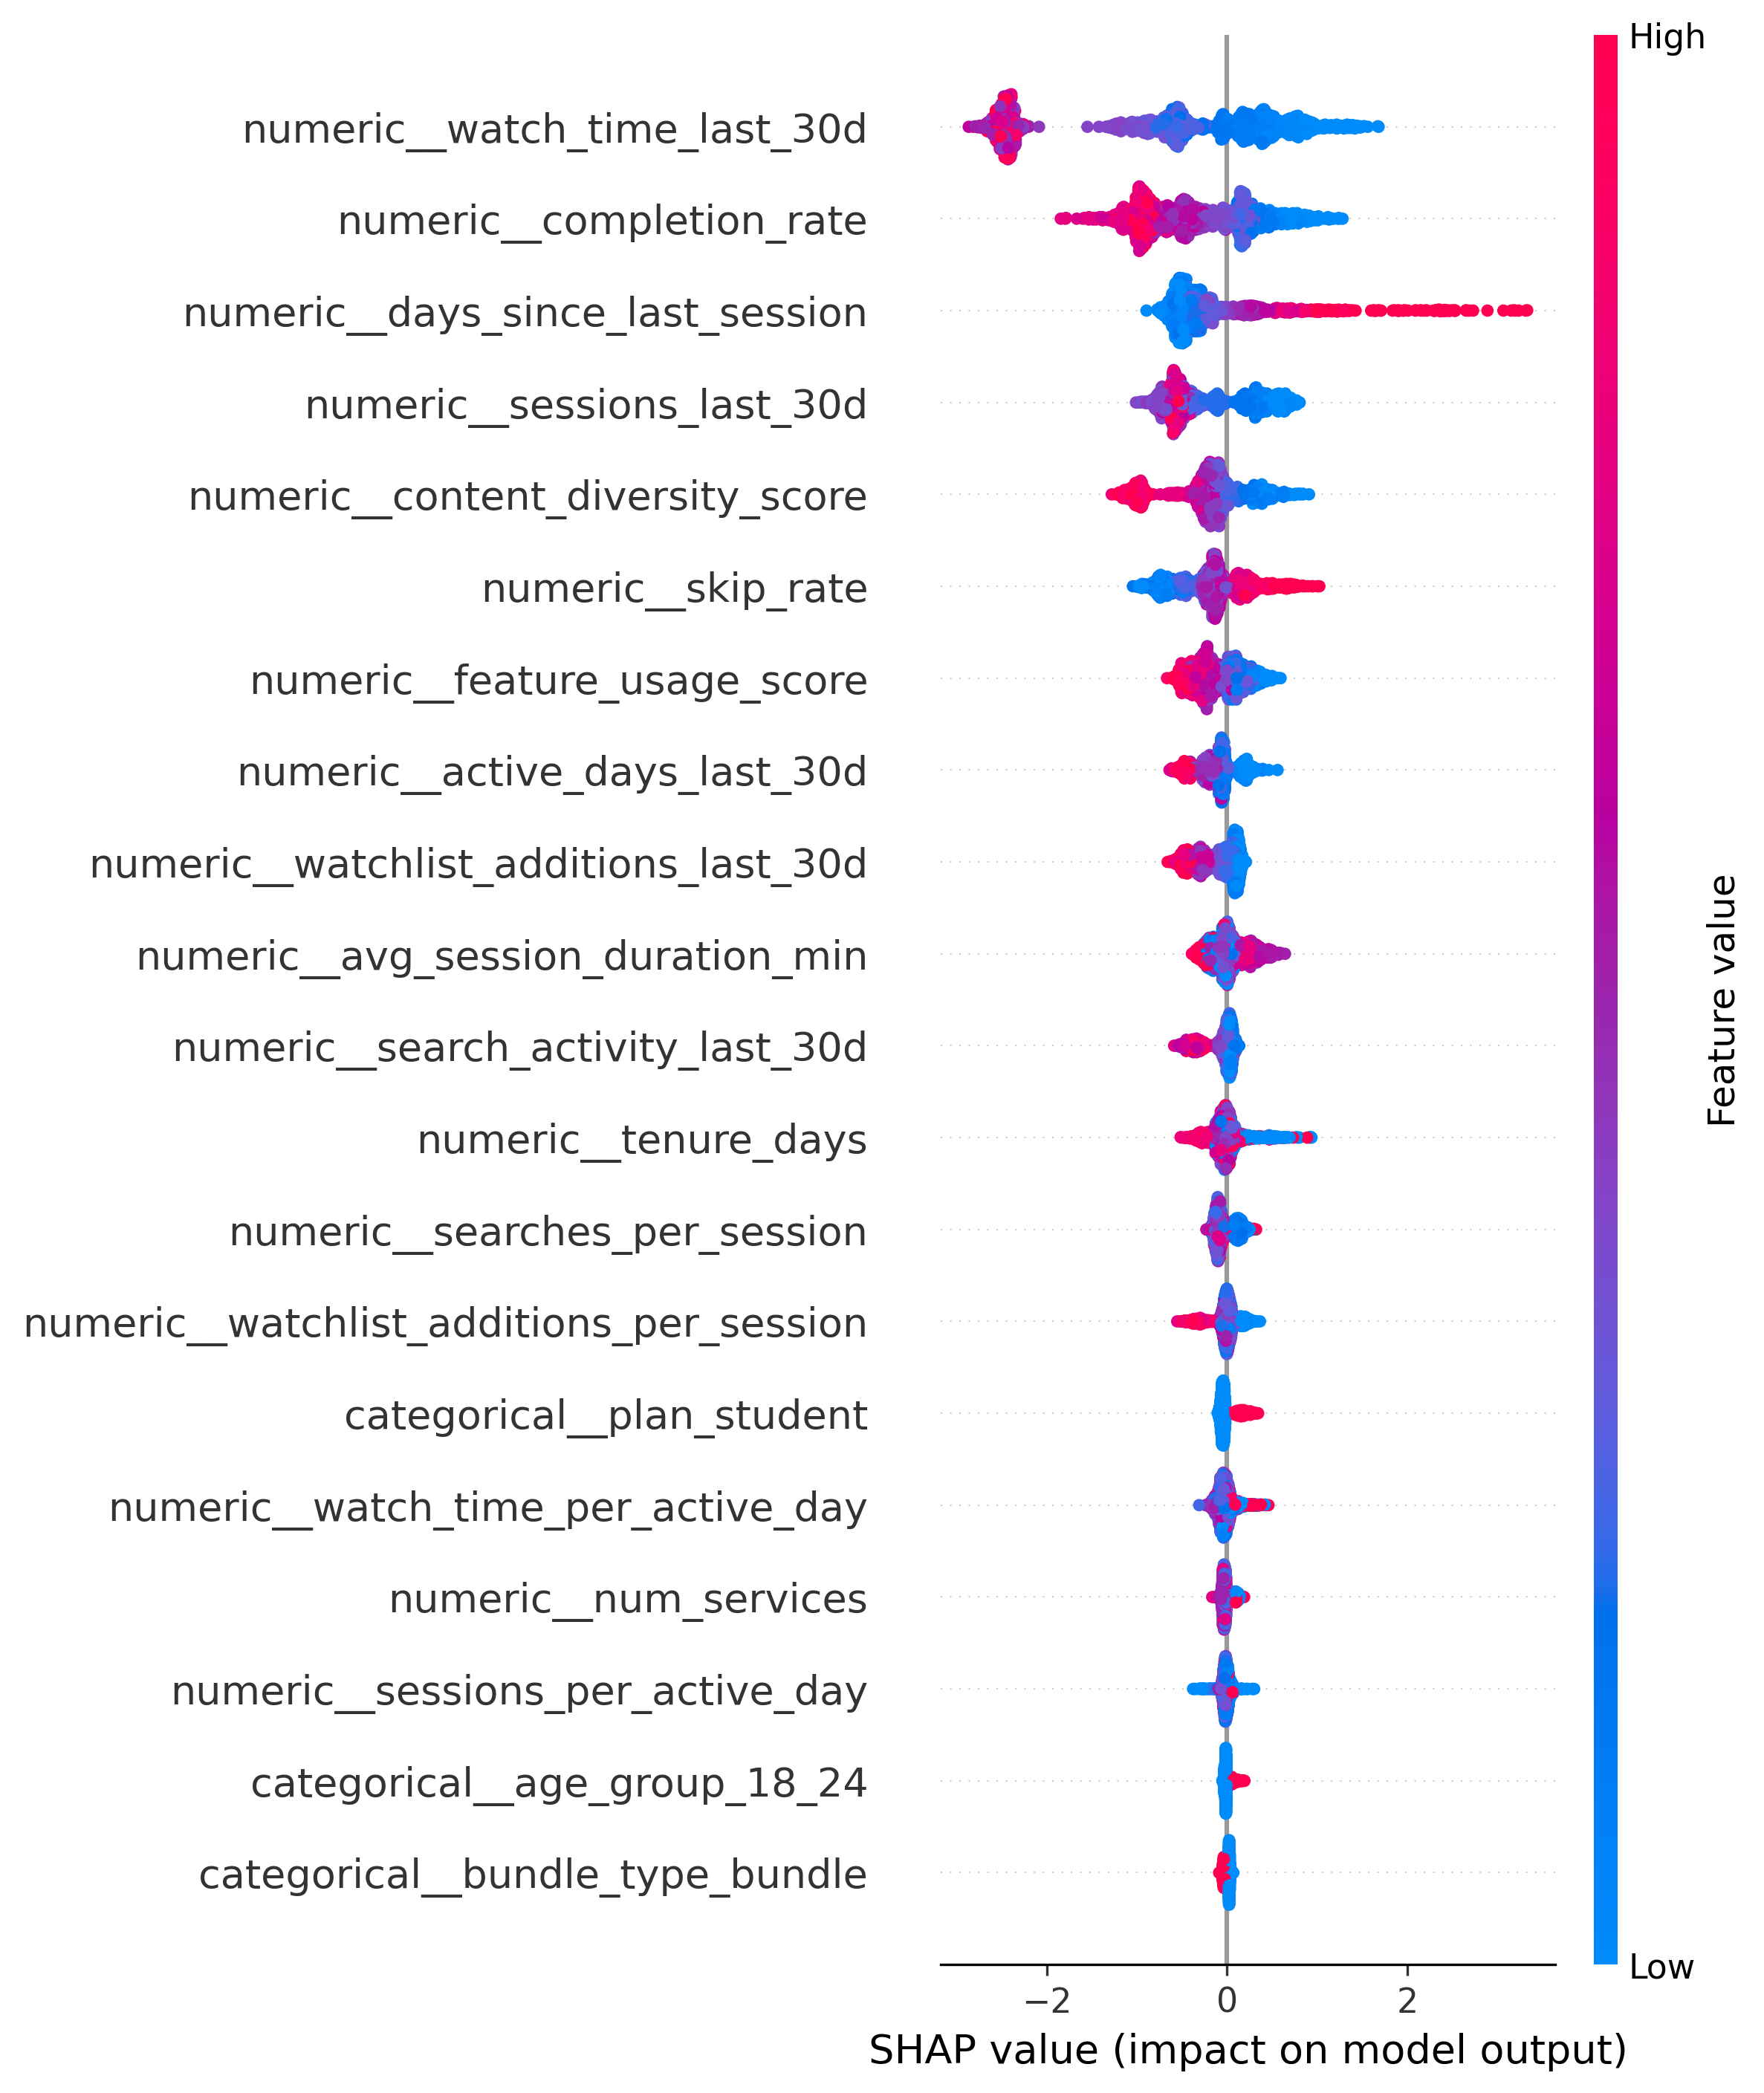

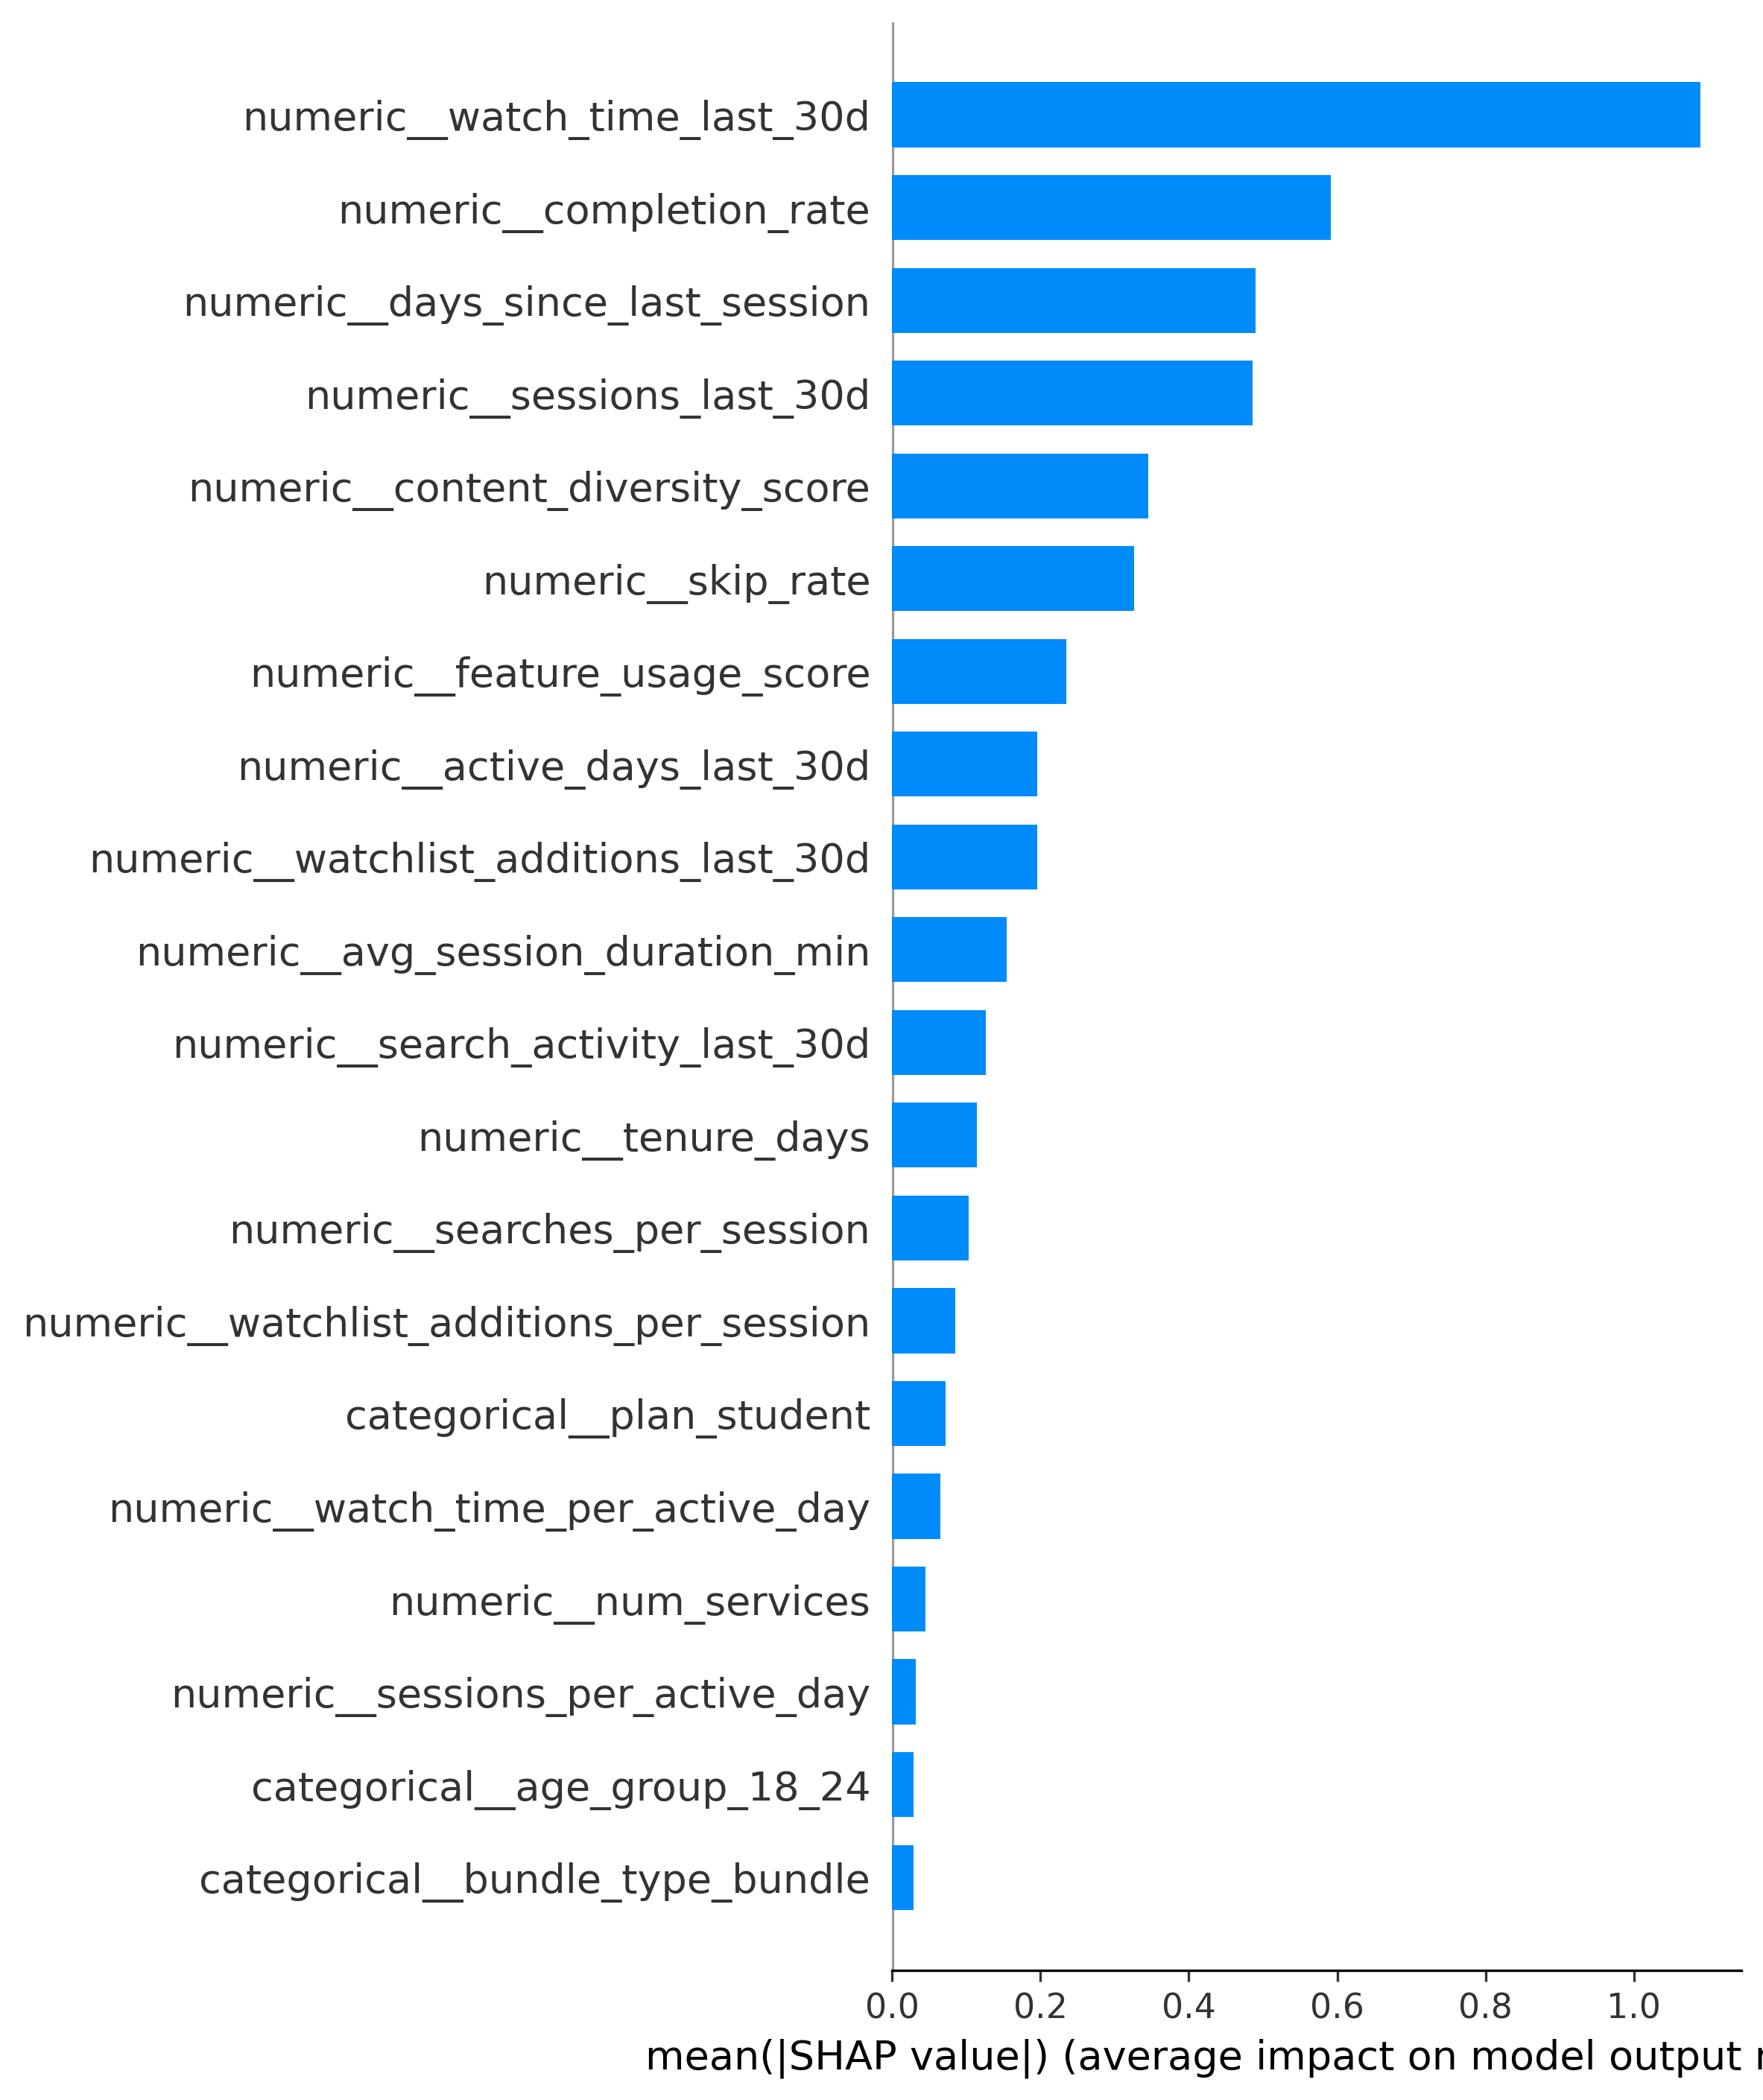

In [14]:
summary_plot_path = ASSETS_DIR / "shap_summary_plot.png"
bar_plot_path = ASSETS_DIR / "shap_bar_importance.png"

if summary_plot_path.exists():
    display(Image(filename=str(summary_plot_path)))

if bar_plot_path.exists():
    display(Image(filename=str(bar_plot_path)))

### Behavioral Insight

The strongest churn predictors indicate that churn is driven primarily by deteriorating engagement patterns rather than demographic characteristics.

Most influential signals include:

- declining watch time,
- reduced completion rate,
- inactivity recency,
- lower content diversity.

This suggests that behavioral disengagement monitoring should be the primary retention trigger.


## 8. Decisioning Outputs

The final layer operationalizes model outputs by combining:

- churn probability,
- SHAP-based driver signals,
- revenue exposure,
- and playbook recommendation logic.

This transforms the system from predictive analytics into actionable decision support.


In [15]:
decision_tier_summary_df

,risk_tier,users,avg_probability,total_revenue_at_risk
0,critical,169,0.830214,2164.065284
1,high,223,0.534603,1891.991751
2,low,1401,0.027598,647.227996
3,medium,207,0.295219,942.619725


In [16]:
decision_playbook_summary_df

,recommended_playbook,users,avg_priority
0,commercial_retention_offer,55,18.646034
1,content_discovery_boost,43,3.103859
2,engagement_quality_recovery,770,1.595055
3,re_engagement_nudge,1132,2.878723


In [17]:
decision_table_df.head(10)

,user_id,y_true,predicted_probability,predicted_label_050,model_name,split,top_driver_1,top_driver_1_shap,top_driver_2,top_driver_2_shap,top_driver_3,top_driver_3_shap,plan,num_services,risk_tier,estimated_monthly_value,revenue_at_risk,priority_score,driver_category,recommended_playbook
0,U000379,1,0.972872,1,xgboost,test,numeric__days_since_last_session,3.325386,numeric__watch_time_last_30d,1.225840,numeric__sessions_last_30d,0.715629,premium,3,critical,25,24.321789,24.321789,engagement_decline,commercial_retention_offer
1,U002045,1,0.884115,1,xgboost,test,numeric__watch_time_last_30d,1.329720,numeric__days_since_last_session,0.819819,numeric__sessions_last_30d,0.555014,premium,4,critical,26,22.986993,22.986993,engagement_decline,commercial_retention_offer
2,U008752,1,0.915721,1,xgboost,test,numeric__days_since_last_session,1.706053,numeric__watch_time_last_30d,0.729869,numeric__sessions_last_30d,0.625925,premium,3,critical,25,22.893018,22.893018,engagement_decline,commercial_retention_offer
3,U005944,1,0.947894,1,xgboost,test,numeric__watch_time_last_30d,1.678918,numeric__days_since_last_session,1.288769,numeric__sessions_last_30d,0.758873,premium,2,critical,24,22.749448,22.749448,engagement_decline,commercial_retention_offer
4,U009307,1,0.935014,1,xgboost,test,numeric__watch_time_last_30d,1.337444,numeric__days_since_last_session,0.830085,numeric__sessions_last_30d,0.530734,premium,2,critical,24,22.440338,22.440338,engagement_decline,commercial_retention_offer
5,U004919,1,0.970194,1,xgboost,test,numeric__days_since_last_session,3.194714,numeric__watch_time_last_30d,0.763652,numeric__feature_usage_score,0.514619,premium,1,critical,23,22.314466,22.314466,engagement_decline,commercial_retention_offer
6,U007117,1,0.905336,1,xgboost,test,numeric__days_since_last_session,1.948409,numeric__completion_rate,0.532265,numeric__avg_session_duration_min,0.484144,premium,2,critical,24,21.728073,21.728073,consumption_quality,commercial_retention_offer
7,U000426,1,0.861641,1,xgboost,test,numeric__days_since_last_session,1.302497,numeric__watch_time_last_30d,0.692812,numeric__sessions_last_30d,0.689159,premium,3,critical,25,21.541035,21.541035,engagement_decline,commercial_retention_offer
8,U008614,1,0.894255,1,xgboost,test,numeric__watch_time_last_30d,0.904331,numeric__completion_rate,0.826626,numeric__skip_rate,0.620018,premium,2,critical,24,21.462117,21.462117,consumption_quality,commercial_retention_offer
9,U000146,1,0.856444,1,xgboost,test,numeric__watch_time_last_30d,1.113986,numeric__days_since_last_session,0.980670,numeric__sessions_last_30d,0.743006,premium,3,critical,25,21.411103,21.411103,engagement_decline,commercial_retention_offer


### Decision Intelligence Interpretation

The final scoring layer transforms raw churn predictions into operational business decisions.

Users are segmented into actionable risk tiers and paired with personalized intervention playbooks based on:

- predicted churn probability,
- behavioral driver analysis,
- revenue exposure,
- and retention priority score.


In [18]:
total_revenue_exposure = decision_table_df["revenue_at_risk"].sum()
critical_users = (decision_table_df["risk_tier"].str.lower() == "critical").sum()

print(f"Critical users identified: {critical_users:,}")
print(f"Total revenue exposure detected: ${total_revenue_exposure:,.0f}")

Critical users identified: 169
Total revenue exposure detected: $5,646


## 9. Strategic Recommendations

Based on the modeled outputs, three business recommendations emerge:

### 1. Prioritize critical high-value users first
A relatively small subset of users drives disproportionate revenue exposure.

### 2. Align intervention strategy with behavioral deterioration type
Different churn drivers require different playbooks.

### 3. Use engagement decay as the earliest warning signal
Recent consumption decline and inactivity are the strongest leading indicators of churn.


## 10. Final Portfolio Takeaways

This case demonstrates the ability to architect and productionize a complete decision intelligence workflow, including:

- predictive analytics,
- explainable machine learning,
- business prioritization frameworks,
- and operational retention strategy design.

Rather than stopping at prediction, the solution bridges analytical outputs into business execution—mirroring real-world Decision Intelligence team workflows.


## Appendix — Portfolio Positioning

This case is designed to demonstrate capability across:

- machine learning system design,
- behavioral analytics,
- explainable AI,
- business-oriented prioritization,
- and executive storytelling.

It is intended as a flagship portfolio case for roles in Apple Decision Intelligence and similar strategic analytics organizations.
